In [1]:
print('test')

test


## 회귀

### 수업에 들어가기 전에(random seed 예제)

In [4]:
import random
import numpy as np

# Random seed 설정
random.seed(42)
np.random.seed(42)

# 난수 생성
random_number1 = random.random()   # 0이상 1미만의 난수를 생성 (1개 생성)
numpy_array1 = np.random.rand(3)   # 0과 1미만의 난수를 3개 생성 (여러개 생성)

print("첫 번째 실행:")
print("Python random:", random_number1)
print("NumPy array:", numpy_array1)

첫 번째 실행:
Python random: 0.6394267984578837
NumPy array: [0.37454012 0.95071431 0.73199394]


In [5]:
# 다시 실행 (random seed 설정 X)
random_number2 = random.random()
numpy_array2 = np.random.rand(3)

print("\n두 번째 실행 (seed 설정 X):")
print("Python random:", random_number2)
print("NumPy array:", numpy_array2)


두 번째 실행 (seed 설정 X):
Python random: 0.025010755222666936
NumPy array: [0.59865848 0.15601864 0.15599452]


In [6]:
# Random seed 설정 후 다시 실행
random.seed(42)
np.random.seed(42)

# 난수 생성
random_number3 = random.random()
numpy_array3 = np.random.rand(3)

print("\n세 번째 실행 (seed 설정):")
print("Python random:", random_number3)
print("NumPy array:", numpy_array3)


세 번째 실행 (seed 설정):
Python random: 0.6394267984578837
NumPy array: [0.37454012 0.95071431 0.73199394]


### 선형회귀

In [2]:
import os
print(os.getcwd())  # 현재 작업 디렉토리 확인
print(os.listdir())  # 현재 디렉토리의 파일 목록 확인

d:\pythonscript\study
['.venv', 'calculator.py', 'calculator_operations.py', 'hello_flask.py', 'ml.ipynb', 'pythonBasic01.ipynb', 'pythonFunction01.ipynb', 'pythonFunction02.ipynb', 'python_dbconn.py']


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
import random

# 재현성(난수가 동일한 순서대로 출력)을 위해 random seed 설정
# random.seed(42)
# np.random.seed(42)

# 데이터 준비
X = np.array([[1],[2],[3],[4],[5]])         # 독립 변수
y = np.array([2, 4, 5, 4, 5])               # 종속 변수

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42)

# 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측
predictions = model.predict(X_test)

# 결과 출력
print("학습 데이터 크기:", X_train.shape[0])
print("테스트 데이터 크기:", X_test.shape[0])
print("\n모델 계수:")
print("기울기 (slope):", model.coef_[0])

print("절편 (intercept):", model.intercept_)
print("\n테스트 세트 실제 값:", y_test)
print("테스트 세트 예측 값:", predictions)
print("\n모델 성능:")
print("R² 점수:", r2_score(y_test, predictions))
print("평균 제곱 오차 (MSE):", mean_squared_error(y_test, predictions))
print("평균 제곱근 오차 (RMSE):", root_mean_squared_error(y_test, predictions))

학습 데이터 크기: 3
테스트 데이터 크기: 2

모델 계수:
기울기 (slope): 0.7857142857142857
절편 (intercept): 1.5714285714285716

테스트 세트 실제 값: [4 5]
테스트 세트 예측 값: [3.14285714 5.5       ]

모델 성능:
R² 점수: -0.9693877551020396
평균 제곱 오차 (MSE): 0.4923469387755099
평균 제곱근 오차 (RMSE): 0.7016743822995891


### 다중선형회귀

In [10]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 샘플 데이터 생성
# 공부 시간(X1)과 과외 시간(X2)에 따른 시험 점수(Y) 예측
study_hours = np.array([2, 3, 4, 5, 4, 6, 7, 8, 5, 4])      # 하루 공부 시간
tutor_hours = np.array([0, 1, 0, 2, 1, 3, 2, 3, 2, 1])      # 주간 과외 시간
test_scores = np.array([60, 70, 75, 85, 75, 90, 92, 95, 80, 75])    # 시험 점수

# 입력 데이터 형태 맞추기
X = np.column_stack((study_hours, tutor_hours))
y = test_scores

# 모델 생성 및 학습
model = LinearRegression()
model.fit(X, y)

# 결과 출력
print("회귀 계수:")
print(f"공부 시간: {model.coef_[0]: .2f}")
print(f"과외 시간: {model.coef_[1]: .2f}")
print(f"절편: {model.intercept_: .2f}")

회귀 계수:
공부 시간:  4.87
과외 시간:  1.94
절편:  53.39


In [11]:
# 새로운 데이터로 예측
new_student = np.array([[6, 2]])      # 공부 6시간, 과외 2시간
prediction = model.predict(new_student)
print(f"\n예측점수: {prediction[0]: .1f}")

# 모델 성능 평가(R-squared)
r_squared = model.score(X, y)
print(f"R-squared: {r_squared: .4f}")


예측점수:  86.5
R-squared:  0.9613


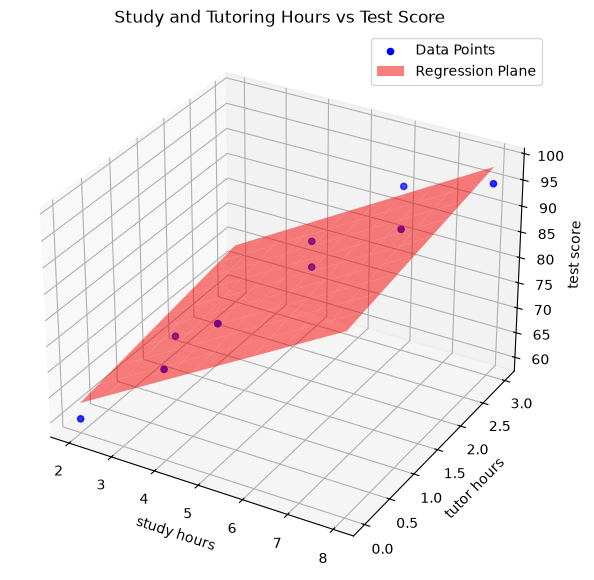

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 3D 시각화
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')      # 111 : 1행 1열 첫 번째 서브 플롯

# 데이터 점 산점도
ax.scatter(study_hours, tutor_hours, test_scores, color='blue', label='Data Points')

# 회귀 평면 생성
# X1, X2 범위의 격자 생성
# 회귀평면 최대값과 최소값 간격을 10개의 균일한 간격으로 나눔
x1_range = np.linspace(min(study_hours), max(study_hours), 10)  
x2_range = np.linspace(min(tutor_hours), max(tutor_hours), 10)

# x1_range와 x2_range를 결합하여 2D 격자(grid)를 생성
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

# 회귀 평면의 Z값(예측 점수) 계산
y_grid = model.intercept_ + model.coef_[0] * x1_grid + model.coef_[1] * x2_grid

# 회귀 평면 그리기
ax.plot_surface(
    x1_grid, x2_grid, y_grid, color='red', alpha=0.5, label="Regression Plane")
    # alpha=0.5: 평면의 투명도

# 축 라벨 설정
ax.set_xlabel('study hours')
ax.set_ylabel('tutor hours')
ax.set_zlabel('test score')
ax.set_title('Study and Tutoring Hours vs Test Score')

# 범례 추가
ax.legend()

plt.show()

회귀 계수:
X1:  1.7882
X2:  2.9284
X3:  0.0135

절편:  4.6535

R-squared 값:  0.9497
평균제곱근오차(RMSE): 0.7174


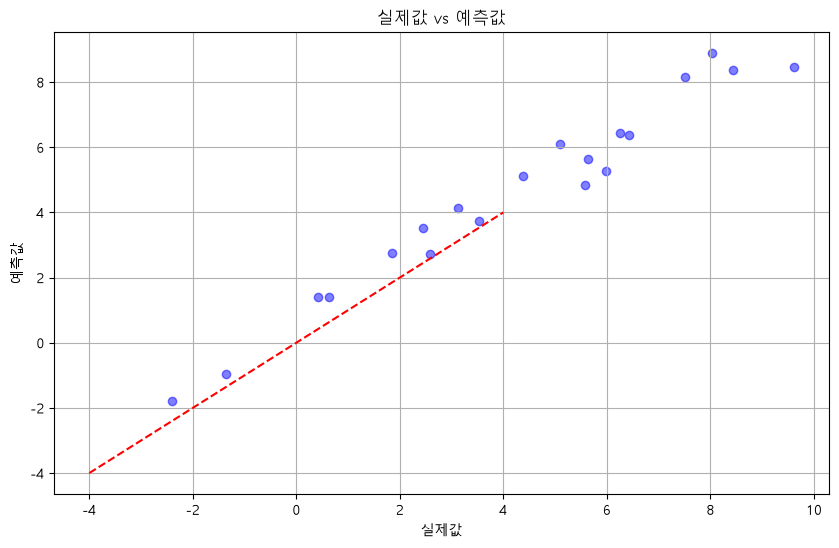


새로운 데이터 예측값: 8.4692


d:\pythonscript\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 폰트 지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{: .2f}'.format

# 샘플 데이터 생성
np.random.seed(42)
n_samples = 100           # 생성할 난수 크기

# 독립변수 생성
#    np.random.normal(평균, 표준편차, 생성할 난수 크기)
X1 = np.random.normal(0, 1, n_samples)  
X2 = np.random.normal(0, 1, n_samples)
X3 = np.random.normal(0, 1, n_samples)

# 종속 변수 생성 (Y = 2X1, 3X2, 1.5X3 + 오차)
Y = 2 * X1 + 3 * X2 + 1.5 * 3 + np.random.normal(0, 1, n_samples)

# 데이터프레임 생성
data = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'Y': Y
})

# 학습용과 테스트용 데이터 분리
X = data[['X1', 'X2', 'X3']]
y = data['Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_test)

# 결과 출력
print("회귀 계수:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef: .4f}")
print(f"\n절편: {model.intercept_: .4f}")
print(f"\nR-squared 값: {r2_score(y_test, y_pred): .4f}")
print(f"평균제곱근오차(RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# 실제값과 예측값 비교 시각화
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5) # alpha(투명도) : 0(투명), 0.5(반투명), 1(완전 불투명)
plt.plot([-4, 4], [-4, 4], 'r--')  # X축 [-4, 4], Y축 [-4, 4]: 이 부분은 선의 시작점과 끝점을 정의 r-- : red색 -- 점선으로 표시
plt.xlabel('실제값')  # Actual value
plt.ylabel('예측값')  # Predicted value
plt.title('실제값 vs 예측값') # Actual value vs Predicted value
plt.grid(True)
plt.show()

# 새로운 데이터로 예측 예시
new_data = np.array([[0.5, 1.0, -0.5]])
prediction = model.predict(new_data)
print(f"\n새로운 데이터 예측값: {prediction[0]:.4f}")